# Using XSuite to perform beam optics

XSuite is a code mainly developed by colleagues in CERN to simulate accelerators. You might not have XSuite installed in your python/jupyter environment. Try the following command 

```
import xtrack
```

If this import does not work, then you might try to install XSuite

```
%pip install xsuite
```

In [7]:
import xtrack as xt
import numpy as np

In [37]:
p0c = 10e9            # reference momentum [eV/c]
L_cell = 20.0         # cell length [m]
L_q = 1.0             # quadrupole length [m]
mu_target = 90.0      # target phase advance per cell [deg]   

# Thin-lens estimate of the focal length for a given phase advance:
# sin(mu/2) = L_cell / (4 f)  ->  f = L_cell / (4 sin(mu/2))
f = L_cell / (4 * np.sin(np.deg2rad(mu_target) / 2))
k1 = 1 / (f * L_q)    # thick quad of length L_q, approx. focal length f

# --- Build one cell ---------------------------------------------------------
# Layout: QF/2 - drift - QD - drift - QF/2  (symmetric cell, starts mid-QF)
L_drift = (L_cell - 2 * L_q) / 2

env = xt.Environment()
env.particle_ref = xt.Particles(p0c=p0c, mass0=xt.PROTON_MASS_EV)
 
env.new('qf', xt.Quadrupole, length=L_q / 2, k1=k1)   # half QF
env.new('qd', xt.Quadrupole, length=L_q, k1=-k1)
env.new('d', xt.Drift, length=L_drift)
 
cell = env.new_line(components=[
    env.place('qf'),
    env.place('d'),
    env.place('qd'),
    env.place('d'),
    env.place('qf'),
])

line = env.new_line(components=[cell])

tw = line.twiss4d()

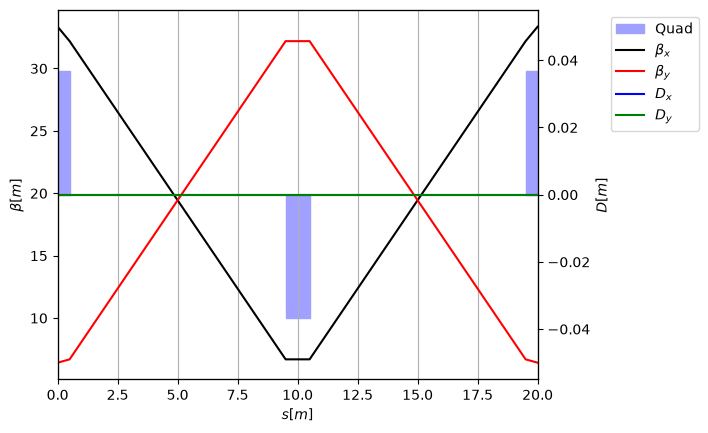

In [38]:
tw.plot()

In [49]:
print('L drift',L_drift)
print('f',f)
print('k1',k1)
print('L_q',L_q)
print('beta0',tw.betx[0])
print('alf0',tw.alfx[0])
print('betx min',tw.betx.min())

L drift 9.0
f 7.0710678118654755
k1 0.1414213562373095
L_q 1.0
beta0 33.34856216607867
alf0 2.465190328815662e-32
betx min 6.6936955668015825
